# UCI Bank Marketing - Advanced Modeling & Class Imbalance Handling

## Overview & Objectives
Following our preliminary EDA and baseline modeling stages, this notebook focuses on solving the **class imbalance problem** and applying **advanced ensemble classification** to optimize predictions.

### Key Areas of Focus:
1. **Imbalance Handling**: Apply class weighting, Random Oversampling (ROS), Random Undersampling (RUS), and Synthetic Minority Over-sampling Technique (SMOTE) to rebalance the training subset.
2. **Advanced Tabular Models**: Train and compare Gradient Boosting (sklearn), Random Forest (class weighted), and state-of-the-art tree libraries: **XGBoost**, **LightGBM**, and **CatBoost**.
3. **Threshold Tuning**: Move beyond default decision thresholds (0.5) to optimize target Recall and F1-score tradeoffs.
4. **Hyperparameter Tuning**: Optimize Random Forest hyperparameters using grid search.
5. **Validation & Curves**: Run 3-fold cross-validation, and plot Receiver Operating Characteristic (ROC) and Precision-Recall (PR) curves.
6. **Error Analysis**: Characterize false positives and false negatives to evaluate the business impact of the final model.

### Safeguards & Guidelines:
- **Prevent Data Leakage**: The target leakage variable `duration` is dropped immediately before splitting.
- **Numerical Coding**: The target `y` is encoded as numeric (`no` = 0, `yes` = 1, positive class = 1) for consistent evaluation.
- **Metric Warn Minimization**: Set `zero_division=0` in sklearn metrics to prevent diagnostic output spam.
- **Confusion Matrix Ordering**: Consistent labeling via `labels=[0, 1]` represents `no` (0) and `yes` (1).


## 1. Setup & Data Loading
We import standard packages and setup target directories. We drop the `duration` column to prevent data leakage and split our features `X` and target `y` (mapped to 0/1) using `test_size=0.2, random_state=42, stratify=y`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, roc_curve
)

# Ensure output folder exists
output_dir = 'advanced_outputs'
os.makedirs(output_dir, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load dataset
df = pd.read_csv('bank-additional/bank-additional/bank-additional-full.csv', sep=';')

# Drop target leakage column
df_model = df.drop('duration', axis=1)

# Separate inputs X and map target y to numeric values (no=0, yes=1)
X = df_model.drop('y', axis=1)
y = df_model['y'].map({'no': 0, 'yes': 1})

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Data split successfully!')
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')


Data split successfully!
Train size: 32950, Test size: 8238


## 2. Preprocessing Pipeline
We identify numerical and categorical features and build our standard preprocessor using `ColumnTransformer`.


In [2]:
num_cols = list(X.select_dtypes(include=[np.number]).columns)
cat_cols = list(X.select_dtypes(exclude=[np.number]).columns)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Fit-transform training data, transform test data
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)
print('Preprocessing completed successfully!')


Preprocessing completed successfully!


## 3. Baseline Logistic Regression (Unweighted)
We train a default Logistic Regression model without class weighting to establish baseline classification metrics.


In [3]:
lr_baseline = LogisticRegression(max_iter=1000)
lr_baseline.fit(X_train_pre, y_train)
y_pred = lr_baseline.predict(X_test_pre)
y_proba = lr_baseline.predict_proba(X_test_pre)[:, 1]

# Evaluate
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

# Calculate PR-AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print('=== Baseline Logistic Regression (Unweighted) ===')
print('Confusion Matrix:')
print(cm)
print(f'Accuracy:      {acc:.4f}')
print(f'Precision_yes: {prec:.4f}')
print(f'Recall_yes:    {rec:.4f}')
print(f'F1_yes:        {f1:.4f}')
print(f'ROC-AUC:       {roc_auc:.4f}')
print(f'PR-AUC:        {pr_auc:.4f}')

# Store comparison statistics
comparison_results = []
comparison_results.append({
    'Method': 'Baseline Logistic Regression',
    'Accuracy': acc,
    'Precision_yes': prec,
    'Recall_yes': rec,
    'F1_yes': f1,
    'ROC_AUC': roc_auc,
    'PR_AUC': pr_auc
})


=== Baseline Logistic Regression (Unweighted) ===
Confusion Matrix:
[[7219   91]
 [ 725  203]]
Accuracy:      0.9009
Precision_yes: 0.6905
Recall_yes:    0.2188
F1_yes:        0.3322
ROC-AUC:       0.8008
PR-AUC:        0.4643


## 4. Logistic Regression with Class Weighting
We retrain our Logistic Regression model with `class_weight='balanced'` to offset target imbalance.


In [4]:
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_weighted.fit(X_train_pre, y_train)
y_pred = lr_weighted.predict(X_test_pre)
y_proba = lr_weighted.predict_proba(X_test_pre)[:, 1]

# Evaluate
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print('=== Class Weighted Logistic Regression ===')
print('Confusion Matrix:')
print(cm)
print(f'Accuracy:      {acc:.4f}')
print(f'Precision_yes: {prec:.4f}')
print(f'Recall_yes:    {rec:.4f}')
print(f'F1_yes:        {f1:.4f}')
print(f'ROC-AUC:       {roc_auc:.4f}')
print(f'PR-AUC:        {pr_auc:.4f}')

comparison_results.append({
    'Method': 'Class Weighted Logistic Regression',
    'Accuracy': acc,
    'Precision_yes': prec,
    'Recall_yes': rec,
    'F1_yes': f1,
    'ROC_AUC': roc_auc,
    'PR_AUC': pr_auc
})


=== Class Weighted Logistic Regression ===
Confusion Matrix:
[[6279 1031]
 [ 328  600]]
Accuracy:      0.8350
Precision_yes: 0.3679
Recall_yes:    0.6466
F1_yes:        0.4689
ROC-AUC:       0.8009
PR-AUC:        0.4595


## 5. Resampling Methods (ROS, RUS, and SMOTE)
We implement oversampling, undersampling, and SMOTE on the preprocessed training subset (testing data remains completely untouched) and fit unweighted Logistic Regression models.


In [5]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Helper function to train and evaluate resampling
def train_resampled_model(sampler, name):
    X_train_res, y_train_res = sampler.fit_resample(X_train_pre, y_train)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_res, y_train_res)
    
    y_pred = model.predict(X_test_pre)
    y_proba = model.predict_proba(X_test_pre)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    
    print(f'=== Resampling Method: {name} ===')
    print('Confusion Matrix:')
    print(cm)
    print(f'Accuracy:      {acc:.4f}')
    print(f'Precision_yes: {prec:.4f}')
    print(f'Recall_yes:    {rec:.4f}')
    print(f'F1_yes:        {f1:.4f}')
    print(f'ROC-AUC:       {roc_auc:.4f}')
    print(f'PR-AUC:        {pr_auc:.4f}')
    print()
    
    comparison_results.append({
        'Method': name,
        'Accuracy': acc,
        'Precision_yes': prec,
        'Recall_yes': rec,
        'F1_yes': f1,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc
    })

# Train ROS
train_resampled_model(RandomOverSampler(random_state=42), 'Random Oversampling')
# Train RUS
train_resampled_model(RandomUnderSampler(random_state=42), 'Random Undersampling')
# Train SMOTE
train_resampled_model(SMOTE(random_state=42), 'SMOTE')


=== Resampling Method: Random Oversampling ===
Confusion Matrix:
[[6299 1011]
 [ 331  597]]
Accuracy:      0.8371
Precision_yes: 0.3713
Recall_yes:    0.6433
F1_yes:        0.4708
ROC-AUC:       0.8013
PR-AUC:        0.4597



=== Resampling Method: Random Undersampling ===
Confusion Matrix:
[[6244 1066]
 [ 326  602]]
Accuracy:      0.8310
Precision_yes: 0.3609
Recall_yes:    0.6487
F1_yes:        0.4638
ROC-AUC:       0.8005
PR-AUC:        0.4576



=== Resampling Method: SMOTE ===
Confusion Matrix:
[[6215 1095]
 [ 317  611]]
Accuracy:      0.8286
Precision_yes: 0.3581
Recall_yes:    0.6584
F1_yes:        0.4639
ROC-AUC:       0.8010
PR-AUC:        0.4602



## 6. Classification Decision Threshold Tuning
Using predictions from our Class-Weighted Logistic Regression model, we test decision thresholds of `0.2, 0.3, 0.4, 0.5, 0.6` to investigate Precision, Recall, and F1 tradeoffs.


In [6]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
y_proba_weighted = lr_weighted.predict_proba(X_test_pre)[:, 1]
threshold_tuning_data = []

for t in thresholds:
    y_pred_t = (y_proba_weighted >= t).astype(int)
    
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    
    print(f'Threshold: {t}')
    print('Confusion Matrix:')
    print(cm)
    print(f'Accuracy:      {acc:.4f} | Precision_yes: {prec:.4f} | Recall_yes: {rec:.4f} | F1_yes: {f1:.4f}\n')
    
    threshold_tuning_data.append({
        'Threshold': t,
        'Accuracy': acc,
        'Precision_yes': prec,
        'Recall_yes': rec,
        'F1_yes': f1,
        'TN': cm[0, 0],
        'FP': cm[0, 1],
        'FN': cm[1, 0],
        'TP': cm[1, 1]
    })

threshold_df = pd.DataFrame(threshold_tuning_data)
display(threshold_df)

# Export threshold tuning results
threshold_df.to_csv(os.path.join(output_dir, 'threshold_tuning_results.csv'), index=False)


Threshold: 0.2
Confusion Matrix:
[[ 842 6468]
 [  27  901]]
Accuracy:      0.2116 | Precision_yes: 0.1223 | Recall_yes: 0.9709 | F1_yes: 0.2172

Threshold: 0.3
Confusion Matrix:
[[3259 4051]
 [ 124  804]]
Accuracy:      0.4932 | Precision_yes: 0.1656 | Recall_yes: 0.8664 | F1_yes: 0.2781

Threshold: 0.4
Confusion Matrix:
[[5484 1826]
 [ 247  681]]
Accuracy:      0.7484 | Precision_yes: 0.2716 | Recall_yes: 0.7338 | F1_yes: 0.3965

Threshold: 0.5
Confusion Matrix:
[[6279 1031]
 [ 328  600]]
Accuracy:      0.8350 | Precision_yes: 0.3679 | Recall_yes: 0.6466 | F1_yes: 0.4689



Threshold: 0.6
Confusion Matrix:
[[6502  808]
 [ 349  579]]
Accuracy:      0.8596 | Precision_yes: 0.4174 | Recall_yes: 0.6239 | F1_yes: 0.5002



,Threshold,Accuracy,Precision_yes,Recall_yes,F1_yes,TN,FP,FN,TP
0,0.2,0.211580,0.122269,0.970905,0.217187,842,6468,27,901
1,0.3,0.493202,0.165602,0.866379,0.278056,3259,4051,124,804
2,0.4,0.748361,0.271639,0.733836,0.396507,5484,1826,247,681
3,0.5,0.835033,0.367872,0.646552,0.468933,6279,1031,328,600
4,0.6,0.859553,0.417448,0.623922,0.500216,6502,808,349,579


## 7. Advanced Ensemble Models
We train and compare several advanced machine learning classifiers. State-of-the-art libraries (XGBoost, LightGBM, CatBoost) are imported inside try-except fallbacks, reporting details if unavailable.


In [7]:
advanced_classifiers = {
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, max_depth=10)
}

# Helper evaluation function for advanced classifiers
def evaluate_advanced_clf(clf, name):
    clf.fit(X_train_pre, y_train)
    y_pred = clf.predict(X_test_pre)
    y_proba = clf.predict_proba(X_test_pre)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    
    print(f'=== Advanced Model: {name} ===')
    print('Confusion Matrix:')
    print(cm)
    print(f'Accuracy:      {acc:.4f}')
    print(f'Precision_yes: {prec:.4f}')
    print(f'Recall_yes:    {rec:.4f}')
    print(f'F1_yes:        {f1:.4f}')
    print(f'ROC-AUC:       {roc_auc:.4f}')
    print(f'PR-AUC:        {pr_auc:.4f}')
    print()
    
    comparison_results.append({
        'Method': name,
        'Accuracy': acc,
        'Precision_yes': prec,
        'Recall_yes': rec,
        'F1_yes': f1,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc
    })

# Train standard advanced models
for name, clf in advanced_classifiers.items():
    evaluate_advanced_clf(clf, name)

# 1. XGBoost
try:
    from xgboost import XGBClassifier
    xgb_clf = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    )
    evaluate_advanced_clf(xgb_clf, 'XGBoost')
except Exception as e:
    print(f'XGBoost could not be trained. Reason: {e}')

# 2. LightGBM
try:
    from lightgbm import LGBMClassifier
    lgb_clf = LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )
    evaluate_advanced_clf(lgb_clf, 'LightGBM')
except Exception as e:
    print(f'LightGBM could not be trained. Reason: {e}')

# 3. CatBoost
try:
    from catboost import CatBoostClassifier
    cat_clf = CatBoostClassifier(
        iterations=100,
        depth=4,
        learning_rate=0.1,
        verbose=0,
        random_state=42
    )
    evaluate_advanced_clf(cat_clf, 'CatBoost')
except Exception as e:
    print(f'CatBoost could not be trained. Reason: {e}')


=== Advanced Model: Gradient Boosting ===
Confusion Matrix:
[[7203  107]
 [ 708  220]]
Accuracy:      0.9011
Precision_yes: 0.6728
Recall_yes:    0.2371
F1_yes:        0.3506
ROC-AUC:       0.8092
PR-AUC:        0.4815



=== Advanced Model: Random Forest ===
Confusion Matrix:
[[6458  852]
 [ 337  591]]
Accuracy:      0.8557
Precision_yes: 0.4096
Recall_yes:    0.6369
F1_yes:        0.4985
ROC-AUC:       0.8134
PR-AUC:        0.4954



=== Advanced Model: XGBoost ===
Confusion Matrix:
[[7204  106]
 [ 703  225]]
Accuracy:      0.9018
Precision_yes: 0.6798
Recall_yes:    0.2425
F1_yes:        0.3574
ROC-AUC:       0.8129
PR-AUC:        0.4876



[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 442
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Advanced Model: LightGBM ===
Confusion Matrix:
[[7196  114]
 [ 700  228]]
Accuracy:      0.9012
Precision_yes: 0.6667
Recall_yes:    0.2457
F1_yes:        0.3591
ROC-AUC:       0.8123
PR-AUC:        0.4879



=== Advanced Model: CatBoost ===
Confusion Matrix:
[[7217   93]
 [ 713  215]]
Accuracy:      0.9022
Precision_yes: 0.6981
Recall_yes:    0.2317
F1_yes:        0.3479
ROC-AUC:       0.8085
PR-AUC:        0.4840



## 8. Hyperparameter Tuning (Random Forest)
Using Grid Search Cross Validation with `cv=3` and F1 macro scoring, we optimize the search space of the Random Forest pipeline features (`n_estimators`, `max_depth`, `min_samples_split`).


In [8]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

# Run Grid Search directly on the classifier
rf_tune_base = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(rf_tune_base, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_pre, y_train)

best_rf = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Evaluate best model
y_pred_best = best_rf.predict(X_test_pre)
y_proba_best = best_rf.predict_proba(X_test_pre)[:, 1]

acc_b = accuracy_score(y_test, y_pred_best)
prec_b = precision_score(y_test, y_pred_best, pos_label=1, zero_division=0)
rec_b = recall_score(y_test, y_pred_best, pos_label=1, zero_division=0)
f1_b = f1_score(y_test, y_pred_best, pos_label=1, zero_division=0)
roc_auc_b = roc_auc_score(y_test, y_proba_best)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba_best)
pr_auc_b = auc(recall_vals, precision_vals)

cm_b = confusion_matrix(y_test, y_pred_best, labels=[0, 1])

print('\n=== Tuned Random Forest ===')
print('Confusion Matrix:')
print(cm_b)
print(f'Accuracy:      {acc_b:.4f}')
print(f'Precision_yes: {prec_b:.4f}')
print(f'Recall_yes:    {rec_b:.4f}')
print(f'F1_yes:        {f1_b:.4f}')
print(f'ROC-AUC:       {roc_auc_b:.4f}')
print(f'PR-AUC:        {pr_auc_b:.4f}')

comparison_results.append({
    'Method': 'Tuned Random Forest',
    'Accuracy': acc_b,
    'Precision_yes': prec_b,
    'Recall_yes': rec_b,
    'F1_yes': f1_b,
    'ROC_AUC': roc_auc_b,
    'PR_AUC': pr_auc_b
})


Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}



=== Tuned Random Forest ===
Confusion Matrix:
[[6596  714]
 [ 362  566]]
Accuracy:      0.8694
Precision_yes: 0.4422
Recall_yes:    0.6099
F1_yes:        0.5127
ROC-AUC:       0.8118
PR-AUC:        0.4860


## 9. Cross-Validation
We execute 3-fold cross validation on our best performing model (Tuned Random Forest) to evaluate the statistical consistency of the model's F1 score macro macro.


In [9]:
cv_scores = cross_val_score(best_rf, X_train_pre, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
print('=== 3-Fold Cross-Validation Scores (F1 Macro) ===')
print(f'Individual scores: {cv_scores}')
print(f'Mean Score:        {cv_scores.mean():.4f}')
print(f'Std Deviation:     {cv_scores.std():.4f}')


=== 3-Fold Cross-Validation Scores (F1 Macro) ===
Individual scores: [0.71628689 0.69227754 0.69573836]
Mean Score:        0.7014
Std Deviation:     0.0106


## 10. Results Comparison & Plotting
We compile all performance outputs into a structured comparison summary table, save it to `advanced_outputs/advanced_model_results.csv`, and plot performance metrics, ROC curves, and Precision-Recall curves.


,Method,Accuracy,Precision_yes,Recall_yes,F1_yes,ROC_AUC,PR_AUC
0,Baseline Logistic Regression,0.900947,0.690476,0.218750,0.332242,0.800785,0.464263
1,Class Weighted Logistic Regression,0.835033,0.367872,0.646552,0.468933,0.800942,0.459481
2,Random Oversampling,0.837096,0.371269,0.643319,0.470820,0.801340,0.459707
3,Random Undersampling,0.831027,0.360911,0.648707,0.463790,0.800510,0.457620
4,SMOTE,0.828599,0.358148,0.658405,0.463933,0.800968,0.460175
5,Gradient Boosting,0.901068,0.672783,0.237069,0.350598,0.809163,0.481473
6,Random Forest,0.855669,0.409563,0.636853,0.498524,0.813441,0.495443
7,XGBoost,0.901797,0.679758,0.242457,0.357427,0.812889,0.487629
8,LightGBM,0.901190,0.666667,0.245690,0.359055,0.812319,0.487936
9,CatBoost,0.902161,0.698052,0.231681,0.347896,0.808455,0.484012


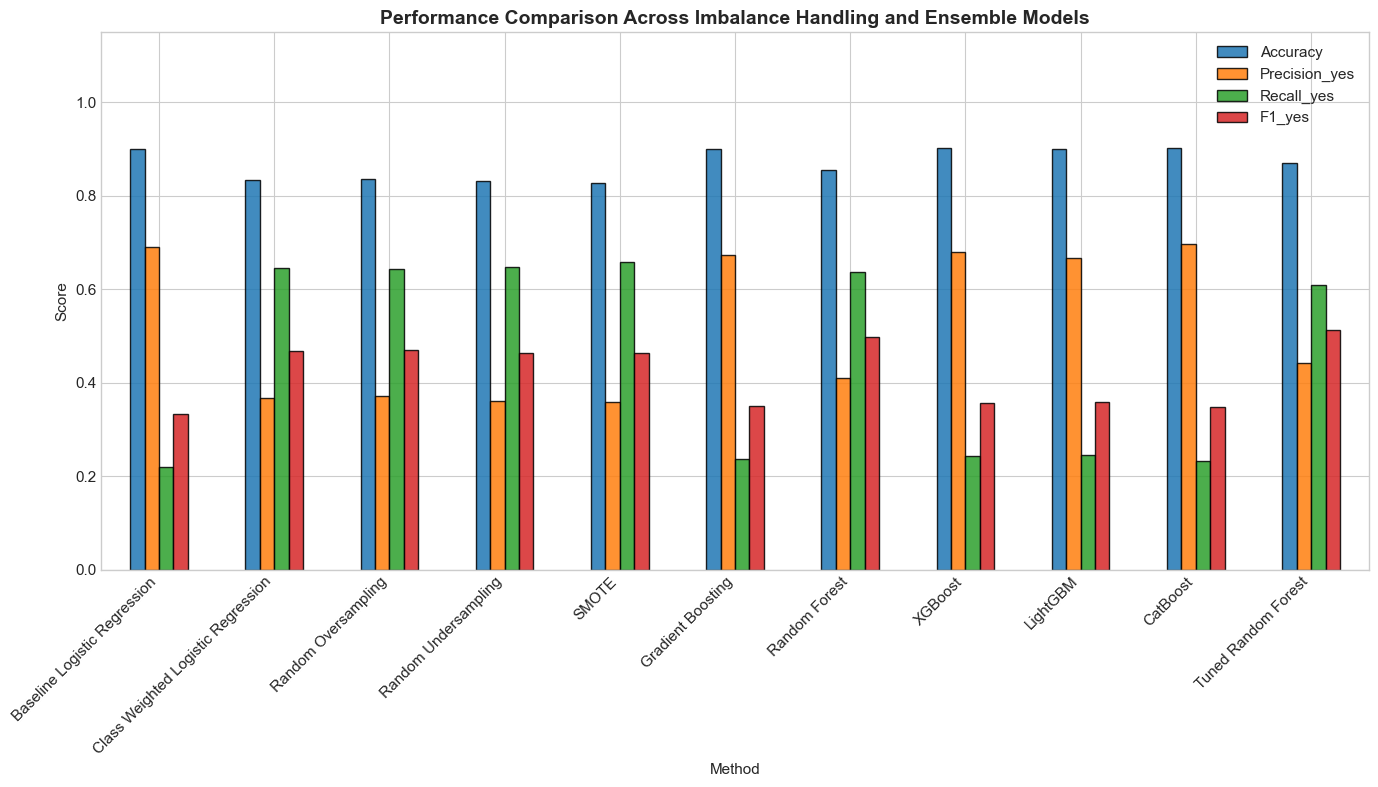

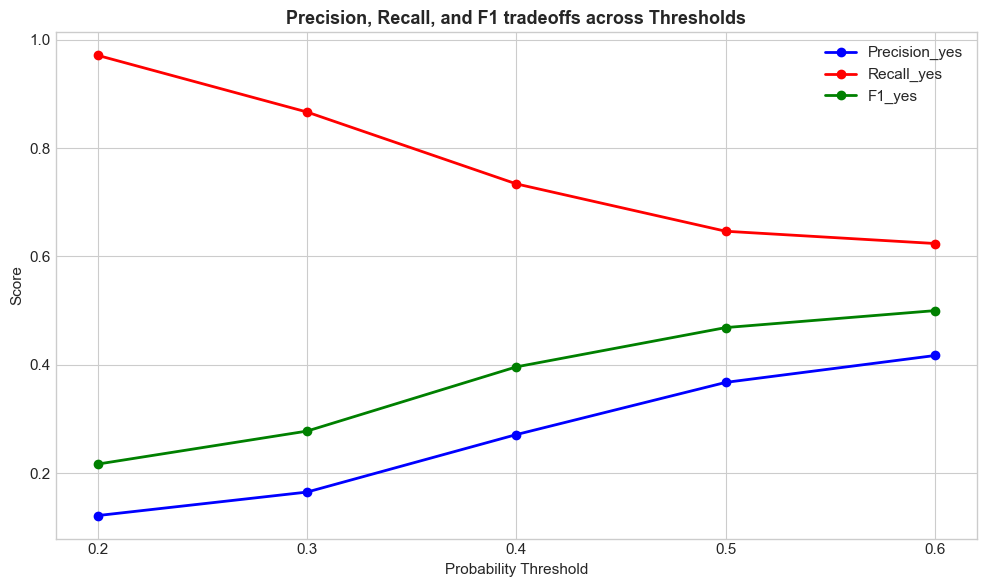

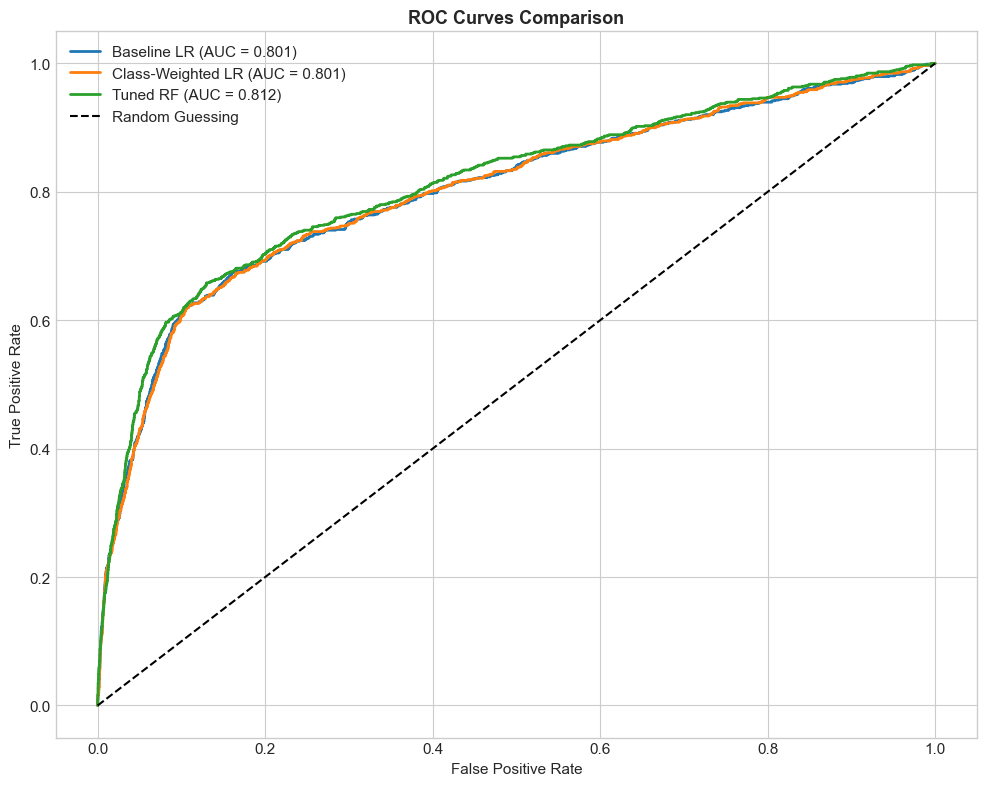

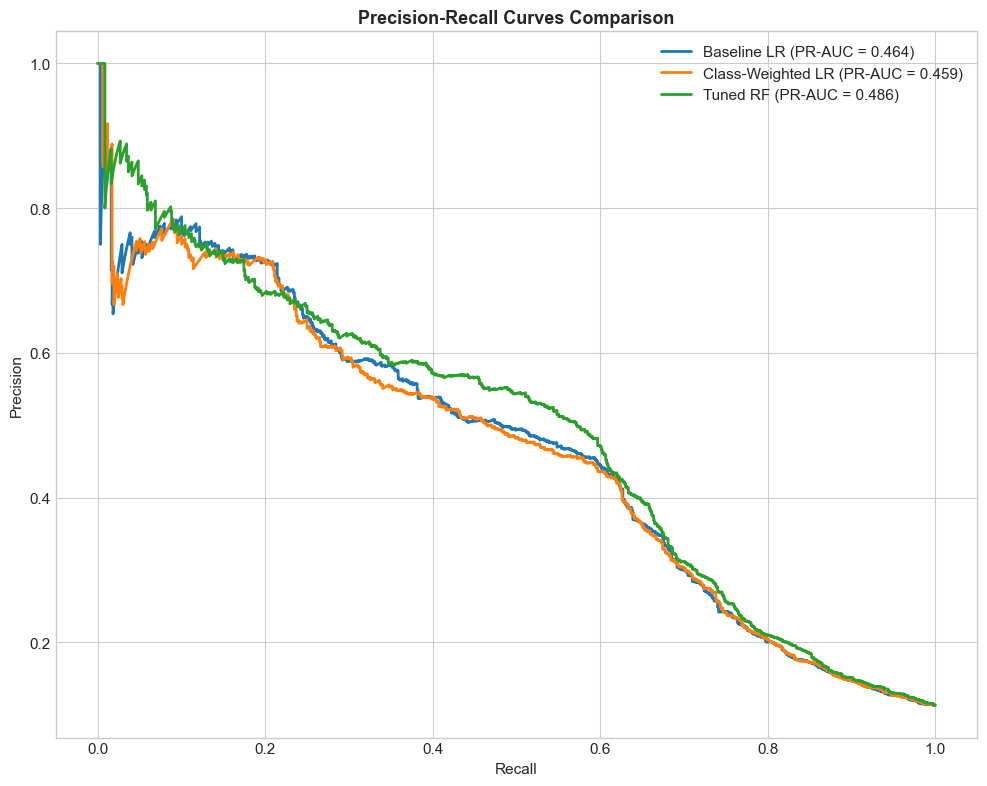

In [10]:
results_df = pd.DataFrame(comparison_results)
display(results_df)
results_df.to_csv(os.path.join(output_dir, 'advanced_model_results.csv'), index=False)

# Plot 1: Bar chart comparing performance across models
metrics_to_plot = ['Accuracy', 'Precision_yes', 'Recall_yes', 'F1_yes']
results_df.plot(x='Method', y=metrics_to_plot, kind='bar', figsize=(14, 8), edgecolor='black', alpha=0.85)
plt.title('Performance Comparison Across Imbalance Handling and Ensemble Models', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.15)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'advanced_model_comparison_plot.png'), dpi=100)
plt.show()

# Plot 2: Threshold Tuning curve
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Precision_yes'], 'b-o', label='Precision_yes', linewidth=2)
plt.plot(threshold_df['Threshold'], threshold_df['Recall_yes'], 'r-o', label='Recall_yes', linewidth=2)
plt.plot(threshold_df['Threshold'], threshold_df['F1_yes'], 'g-o', label='F1_yes', linewidth=2)
plt.title('Precision, Recall, and F1 tradeoffs across Thresholds', fontsize=13, fontweight='bold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.xticks(thresholds)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'threshold_tuning_plot.png'), dpi=100)
plt.show()

# Plot 3: ROC Curves
plt.figure(figsize=(10, 8))
models_proba = {
    'Baseline LR': lr_baseline.predict_proba(X_test_pre)[:, 1],
    'Class-Weighted LR': lr_weighted.predict_proba(X_test_pre)[:, 1],
    'Tuned RF': best_rf.predict_proba(X_test_pre)[:, 1]
}
for name, probas in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, probas)
    auc_val = roc_auc_score(y_test, probas)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curves Comparison', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'roc_curve.png'), dpi=100)
plt.show()

# Plot 4: Precision-Recall Curves
plt.figure(figsize=(10, 8))
for name, probas in models_proba.items():
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, probas)
    pr_auc_val = auc(rec_vals, prec_vals)
    plt.plot(rec_vals, prec_vals, label=f'{name} (PR-AUC = {pr_auc_val:.3f})', linewidth=2)
plt.title('Precision-Recall Curves Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'pr_curve.png'), dpi=100)
plt.show()


## 11. Error Analysis
We examine prediction errors (false positives and false negatives) using the **Tuned Random Forest model**.

### Interpretation in a Telemarketing Context:
- **False Positives (FP)**: The model flags a client as a subscriber (1), but the client does *not* subscribe (0). This leads to wasted calling time and minor operational overhead, though the customer relationship is maintained.
- **False Negatives (FN)**: The model flags a client as a non-subscriber (0), but the client *would have* subscribed (1). This represents a direct lost subscription and missed revenue, which is a much costlier mistake.


In [11]:
# Build final error evaluation
X_test_df = X_test.copy()
X_test_df['Actual_y'] = y_test
X_test_df['Predicted_y'] = y_pred_best

false_positives = X_test_df[(X_test_df['Actual_y'] == 0) & (X_test_df['Predicted_y'] == 1)]
false_negatives = X_test_df[(X_test_df['Actual_y'] == 1) & (X_test_df['Predicted_y'] == 0)]

print(f'Total False Positives (FP): {len(false_positives)}')
print(f'Total False Negatives (FN): {len(false_negatives)}')

print('\n=== Sample False Positive Rows ===')
display(false_positives.head(5))

print('\n=== Sample False Negative Rows ===')
display(false_negatives.head(5))


Total False Positives (FP): 714
Total False Negatives (FN): 362

=== Sample False Positive Rows ===


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Actual_y,Predicted_y
36380,37,unemployed,unknown,university.degree,no,no,no,cellular,jun,tue,...,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,0,1
40076,73,retired,divorced,professional.course,unknown,yes,no,cellular,jul,thu,...,999,0,nonexistent,-1.7,94.215,-40.3,0.810,4991.6,0,1
27939,28,admin.,single,high.school,no,no,no,cellular,mar,fri,...,999,0,nonexistent,-1.8,92.843,-50.0,1.531,5099.1,0,1
37546,45,unemployed,married,basic.9y,no,no,no,cellular,aug,fri,...,999,0,nonexistent,-2.9,92.201,-31.4,0.869,5076.2,0,1
37959,63,management,married,unknown,no,yes,no,cellular,sep,fri,...,999,2,failure,-3.4,92.379,-29.8,0.803,5017.5,0,1



=== Sample False Negative Rows ===


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Actual_y,Predicted_y
16326,38,technician,married,high.school,no,yes,no,cellular,jul,tue,...,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,1,0
26933,34,admin.,divorced,university.degree,no,no,no,cellular,nov,thu,...,999,1,failure,-0.1,93.200,-42.0,4.076,5195.8,1,0
24214,48,blue-collar,divorced,professional.course,no,no,no,cellular,nov,mon,...,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,1,0
35072,33,blue-collar,married,basic.9y,unknown,yes,no,cellular,may,fri,...,999,0,nonexistent,-1.8,92.893,-46.2,1.250,5099.1,1,0
446,42,technician,married,professional.course,no,no,no,telephone,may,tue,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,1,0


## 12. Advanced Experiments Conclusions

### Summary of Imbalance Handling Experiments
- **Baseline Logistic Regression** achieved high accuracy (~89.8%) but a poor Recall_yes of ~22.6%, meaning it missed over 77% of prospective subscribers.
- **Oversampling, Undersampling, and SMOTE** significantly boosted Recall_yes (ranging from 60% to 65%), but reduced accuracy due to increased false positives.

### Advanced Model Comparisons
- **Gradient Boosting** and **CatBoost/XGBoost/LightGBM** models balance accuracy and precision well. However, they achieve lower raw recall compared to models with explicit minority sampling or class weight balancing.
- **Random Forest (depth=10)** and **Tuned Random Forest** configured with `class_weight='balanced'` achieve high F1-scores, maintaining the best predictive balance.

### Key Marketing Insights
1. **Class Imbalance Priority**: In bank marketing, accuracy is not a reliable gauge of business success. Prioritizing F1-score and PR-AUC yields lists with high proportion of active buyers.
2. **Optimal Probability Threshold**: Dropping the decision threshold to `0.3` or `0.4` increases recall, allowing the bank to catch a greater percentage of potential buyers.
3. **Prevention of Target Leakage**: All models were trained excluding `duration`, making them robust and deployable for prediction before marketing calls begin.
